In [1]:
import pandas as pd
import numpy as np

# ML models
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Data prep
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import numpy as np


# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
df = pd.read_csv('spam.csv', encoding='latin-1')
df = df[['Category', 'Message']]
df.columns = ['label', 'message']
df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# Encode labels
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    df['message'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

# TF-IDF vectorization
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.95)
#Fit & transform training data
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [ ]:
# ==============================
# Balance the training data with SMOTE
# ==============================

!pip install -q imbalanced-learn
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE on the vectorized training data
X_train_bal, y_train_bal = smote.fit_resample(X_train_vec, y_train)

# Check new class distribution
import pandas as pd
print("Before SMOTE:\n", y_train.value_counts())
print("After SMOTE:\n", pd.Series(y_train_bal).value_counts())


Before SMOTE:
 label
0    409
1     70
Name: count, dtype: int64
After SMOTE:
 label
0    409
1    409
Name: count, dtype: int64


In [ ]:
from sklearn.svm import LinearSVC

# Train the best-performing SVM on SMOTE-balanced data
svm_model = LinearSVC()
svm_model.fit(X_train_bal, y_train_bal)


LinearSVC()

In [ ]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }


In [ ]:
#Non-ensemble Models Performance Table
non_ensemble_results = []

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Support Vector Machine (SVM)': LinearSVC()
}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    metrics = evaluate_model(model, X_test_vec, y_test)
    metrics['Model'] = name
    non_ensemble_results.append(metrics)

non_ensemble_df = pd.DataFrame(non_ensemble_results)
non_ensemble_df


,Accuracy,Precision,Recall,F1-Score,Model
0,0.891667,0.727273,0.444444,0.551724,Decision Tree
1,0.883333,0.566667,0.944444,0.708333,Naive Bayes
2,0.991667,1.000000,0.944444,0.971429,Support Vector Machine (SVM)


In [ ]:
#Ensemble Models Performance Table (Before Hyperparameter tuning)
ensemble_before_results = []

ensemble_models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Bagging': BaggingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

for name, model in ensemble_models.items():
    model.fit(X_train_bal, y_train_bal)
    metrics = evaluate_model(model, X_test_vec, y_test)
    metrics['Model'] = name
    ensemble_before_results.append(metrics)

ensemble_before_df = pd.DataFrame(ensemble_before_results)
ensemble_before_df


,Accuracy,Precision,Recall,F1-Score,Model
0,0.925000,1.000000,0.500000,0.666667,Random Forest
1,0.900000,0.714286,0.555556,0.625000,Bagging
2,0.908333,0.733333,0.611111,0.666667,AdaBoost


In [ ]:
#RANDOM FOREST
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20, 40]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

rf_grid.fit(X_train_bal, y_train_bal)
best_rf = rf_grid.best_estimator_
rf_grid.best_params_


{'max_depth': None, 'n_estimators': 100}

In [ ]:
#BAGGING
bag_params = {
    'n_estimators': [50, 100]
}

bag_grid = GridSearchCV(
    BaggingClassifier(random_state=42),
    bag_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

bag_grid.fit(X_train_bal, y_train_bal)
best_bag = bag_grid.best_estimator_
bag_grid.best_params_


{'n_estimators': 50}

In [ ]:
#ADA BOOST
ada_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.5, 1.0]
}

ada_grid = GridSearchCV(
    AdaBoostClassifier(random_state=42),
    ada_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

ada_grid.fit(X_train_bal, y_train_bal)
best_ada = ada_grid.best_estimator_
ada_grid.best_params_


{'learning_rate': 1.0, 'n_estimators': 100}

In [ ]:
#Ensemble Learning Models Performance Table (After Hyperparameter tuning)
ensemble_after_results = []

best_models = {
    'Random Forest (Tuned)': best_rf,
    'Bagging (Tuned)': best_bag,
    'AdaBoost (Tuned)': best_ada
}

for name, model in best_models.items():
    metrics = evaluate_model(model, X_test_vec, y_test)
    metrics['Model'] = name
    ensemble_after_results.append(metrics)

ensemble_after_df = pd.DataFrame(ensemble_after_results)
ensemble_after_df


,Accuracy,Precision,Recall,F1-Score,Model
0,0.925,1.000000,0.500000,0.666667,Random Forest (Tuned)
1,0.900,0.714286,0.555556,0.625000,Bagging (Tuned)
2,0.925,0.846154,0.611111,0.709677,AdaBoost (Tuned)


In [ ]:
#HYPERPARAMETER DETAILS TABLE
hyperparameter_table = pd.DataFrame({
    'Model': ['Random Forest', 'Bagging', 'AdaBoost'],
    'Hyperparameters Tuned': [
        str(rf_params),
        str(bag_params),
        str(ada_params)
    ],
    'Best Values': [
        rf_grid.best_params_,
        bag_grid.best_params_,
        ada_grid.best_params_
    ]
})

hyperparameter_table


,Model,Hyperparameters Tuned,Best Values
0,Random Forest,"{'n_estimators': [100, 200], 'max_depth': [Non...","{'max_depth': None, 'n_estimators': 100}"
1,Bagging,"{'n_estimators': [50, 100]}",{'n_estimators': 50}
2,AdaBoost,"{'n_estimators': [50, 100], 'learning_rate': [...","{'learning_rate': 1.0, 'n_estimators': 100}"


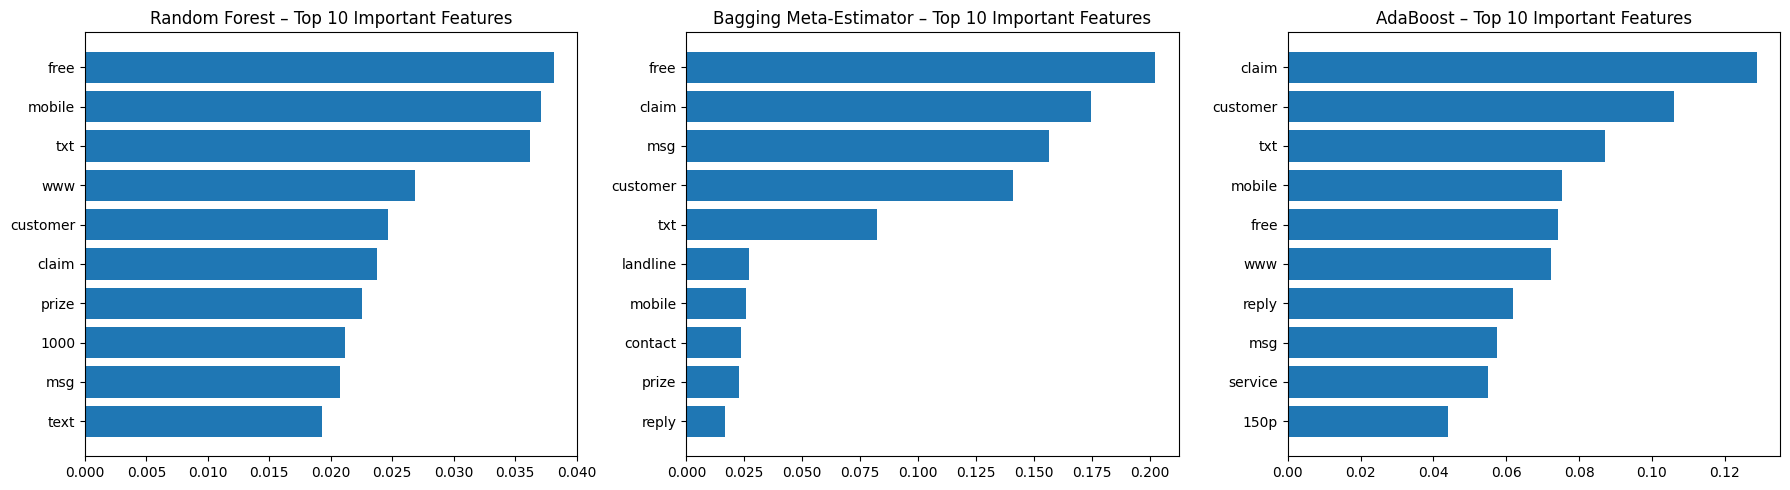

In [ ]:
# ==============================
# Feature Selection Analysis
# ==============================

# Get feature names from TF-IDF
feature_names = vectorizer.get_feature_names_out()

# Ensure ensemble models are defined
rf_model = best_rf      # tuned Random Forest
ada_model = best_ada    # tuned AdaBoost

# Bagging needs explicit base estimator
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42
)
bagging_model.fit(X_train_bal, y_train_bal)

import matplotlib.pyplot as plt
import numpy as np

models = [
    ("Random Forest", rf_model),
    ("Bagging Meta-Estimator", bagging_model),
    ("AdaBoost", ada_model)
]

plt.figure(figsize=(18, 5))

for i, (name, model) in enumerate(models, 1):

    if name == "Bagging Meta-Estimator":
        importances = np.mean(
            [est.feature_importances_ for est in model.estimators_],
            axis=0
        )
    else:
        importances = model.feature_importances_

    top_indices = np.argsort(importances)[-10:]

    plt.subplot(1, 3, i)
    plt.barh(range(10), importances[top_indices])
    plt.yticks(range(10), [feature_names[j] for j in top_indices])
    plt.title(f"{name} – Top 10 Important Features")

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1000)

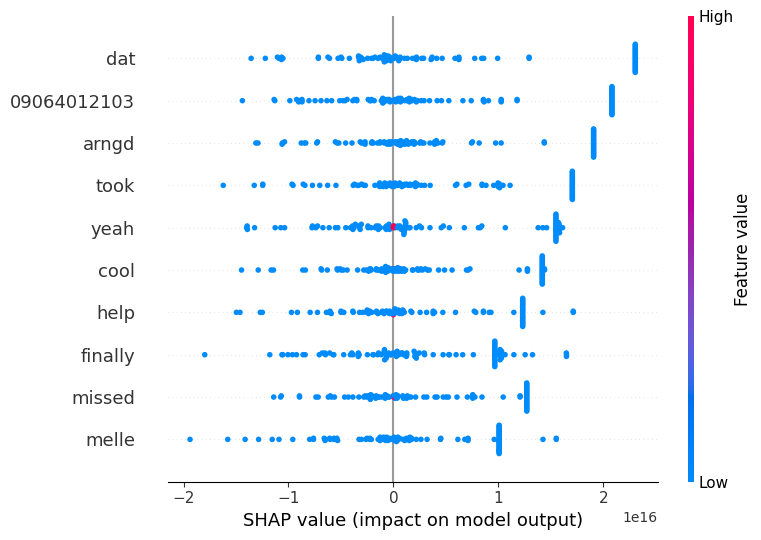

In [ ]:
# Install SHAP (Colab only)
!pip install shap
import shap
import numpy as np

# Small dense sample
X_sample = X_test_vec[:100].toarray()

# SHAP explainer
explainer = shap.TreeExplainer(rf_model)

# Compute SHAP values (disable additivity check)
shap_values = explainer.shap_values(
    X_sample,
    check_additivity=False
)

# Summary plot
shap.summary_plot(
    shap_values[:, :, 1], # Correctly select SHAP values for class 1 (spam)
    X_sample,
    feature_names=feature_names,
    max_display=10
)

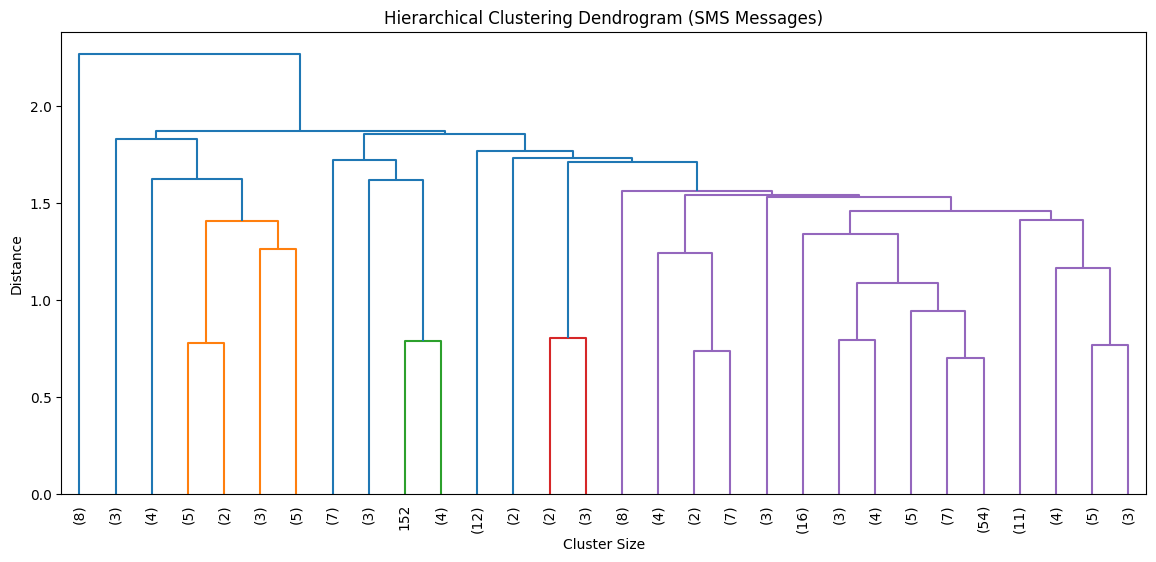

In [ ]:
#DENDOGRAM
# Take a small sample (e.g., 200 messages)
sample_size = 200
X_sample = X_train_vec[:sample_size]

# Reduce dimensions (TF-IDF is high-dimensional)
svd = TruncatedSVD(n_components=20, random_state=42)
X_reduced = svd.fit_transform(X_sample)

# Hierarchical clustering
linked = linkage(X_reduced, method='ward')

# Plot dendrogram
plt.figure(figsize=(14, 6))
dendrogram(
    linked,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title("Hierarchical Clustering Dendrogram (SMS Messages)")
plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.show()
